<a href="https://colab.research.google.com/github/zhangminxi-bit/ECON3916/blob/main/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [2]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [15]:
# Bootstrap parameters
n_bootstrap = 10000
n = len(driver_tips)

# Storage for bootstrap medians
bootstrap_medians = np.empty(n_bootstrap)

# Manual bootstrap loop
for i in range(n_bootstrap):

    sample = np.random.choice(driver_tips, size=n, replace=True)
    bootstrap_medians[i] = np.median(sample)

# 95% confidence interval
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print("95% Bootstrap CI for Median:", ci_lower, ci_upper)

print("The 95% confidence interval is asymmetric because, comparing to regular distributions, the studied distribution is heavily right-skewed with a large mass at zero. This will make the upper tail longer than regular distributions.")


95% Bootstrap CI for Median: 0.26850654591272305 1.2990257845869702
The 95% confidence interval is asymmetric because, comparing to regular distributions, the studied distribution is heavily right-skewed with a large mass at zero. This will make the upper tail longer than regular distributions.


In [5]:
np.random.seed(42)

# Sample sizes
n = 500

# Control group (Normal)
control = np.random.normal(loc=35, scale=5, size=n)

# Treatment group (Log-Normal)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=n)

# Calculate means
control_mean = np.mean(control)
treatment_mean = np.mean(treatment)

# Observed difference
observed_diff = control_mean - treatment_mean

print("Control Mean:", control_mean)
print("Treatment Mean:", treatment_mean)
print("Observed Difference (Control - Treatment):", observed_diff)

Control Mean: 35.03418997294323
Treatment Mean: 32.76920784231749
Observed Difference (Control - Treatment): 2.2649821306257394


In [20]:
# Observed difference
observed_diff = np.mean(control) - np.mean(treatment)

# Combine all deliveries
all_deliveries = np.concatenate([control, treatment])

# Permutation test
n_perm = 5000
perm_diffs = np.empty(n_perm)

for i in range(n_perm):

    shuffled = np.random.permutation(all_deliveries)

    group1 = shuffled[:500]
    group2 = shuffled[500:]

    perm_diffs[i] = np.mean(group1) - np.mean(group2)

# Empirical p-value
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print("Observed Difference:", observed_diff)
print("Empirical P-value:", p_value)

print(f"The empirical p-value is {p_value} in this case (<0.05), which means about {p_value*100}% of the 5,000 permutations produced a difference this extreme.")

Observed Difference: 2.2649821306257394
Empirical P-value: 0.0004
The empirical p-value is 0.0004 in this case (<0.05), which means about 0.04% of the 5,000 permutations produced a difference this extreme.


In [22]:
df = pd.read_csv("swiftcart_loyalty.csv")

subscriber_mean = df[df["subscriber"] == 1]["post_spend"].mean()
nonsubscriber_mean = df[df["subscriber"] == 0]["post_spend"].mean()

sdo = subscriber_mean - nonsubscriber_mean

print("Subscriber Mean Spending:", subscriber_mean)
print("Non-Subscriber Mean Spending:", nonsubscriber_mean)
print("Naive Simple Difference in Means (SDO):", sdo)

print(f"Conclusion: subscribers spend around ${sdo:.2f} more per month on average.")

Subscriber Mean Spending: 74.04358604052543
Non-Subscriber Mean Spending: 56.47291665600164
Naive Simple Difference in Means (SDO): 17.57066938452379
Conclusion: subscribers spend around $17.57 more per month on average.


In [44]:
# Pre-treatment covariates
X = df[["pre_spend", "account_age", "support_tickets"]]

# Treatment indicator
D = df["subscriber"]

# Logistic regression
logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

# Predicted propensity scores
df["propensity_score"] = logit.predict_proba(X)[:,1]

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

# Fit nearest neighbor search on control group propensity scores
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

# Find closest control match for each treated user
distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_controls = control.iloc[indices.flatten()]

treated_spend = treated["post_spend"].values
control_spend = matched_controls["post_spend"].values

ATT = (treated_spend - control_spend).mean()

print("ATT (Matched Estimate):", ATT)
print("Naive Simple Difference in Means (SDO):", sdo)

print(
    "The naive Simple Difference in Means indicates that the average SwiftPass subscriber spends significantly more than the average non-subscriber.However, the naive Difference in Means is a biased estimator because high-frequency users are more likely to enroll in the SwiftPass program. We use logistic regression to calculate the probability of each user subscribing based on pre-treatment characteristics such as order volume and age of the account, as well as the number of support tickets. We then pair each subscriber with the closest non-subscriber based on the propensity score using a nearest neighbor algorithm. The resulting Average Treatment Effect on the Treated (ATT) compares the SwiftPass subscriber to the closest non-subscriber. The ATT is generally much lower than the naive Difference in Means, showing that the vast majority of the observed difference in average spend is due to selection bias rather than the effect of the loyalty program."
    )


ATT (Matched Estimate): 9.913855182824864
Naive Simple Difference in Means (SDO): 17.57066938452379
The naive Simple Difference in Means indicates that the average SwiftPass subscriber spends significantly more than the average non-subscriber.However, the naive Difference in Means is a biased estimator because high-frequency users are more likely to enroll in the SwiftPass program. We use logistic regression to calculate the probability of each user subscribing based on pre-treatment characteristics such as order volume and age of the account, as well as the number of support tickets. We then pair each subscriber with the closest non-subscriber based on the propensity score using a nearest neighbor algorithm. The resulting Average Treatment Effect on the Treated (ATT) compares the SwiftPass subscriber to the closest non-subscriber. The ATT is generally much lower than the naive Difference in Means, showing that the vast majority of the observed difference in average spend is due to sel

In [46]:
# Reconstruct df_unmatched and df_matched for the Love Plot
df_unmatched = df.copy()
df_matched = pd.concat([treated, matched_controls])

# Define the treatment column and covariates
treatment_col = 'subscriber'
covariates = ['pre_spend', 'account_age', 'support_tickets']

# Function to compute standardized mean differences
def calculate_smd(data, treatment_col, covariates):
    smd_values = {}
    for col in covariates:
        mean_treated = data[data[treatment_col] == 1][col].mean()
        mean_control = data[data[treatment_col] == 0][col].mean()
        std_treated = data[data[treatment_col] == 1][col].std()
        std_control = data[data[treatment_col] == 0][col].std()

        # Pooled standard deviation (recommended for SMD calculation)
        pooled_std = np.sqrt(((std_treated**2) + (std_control**2)) / 2)
        smd = (mean_treated - mean_control) / pooled_std
        smd_values[col] = smd
    return pd.Series(smd_values)

# Calculate SMDs before matching
smd_unmatched = calculate_smd(df_unmatched, treatment_col, covariates)

# Calculate SMDs after matching
smd_matched = calculate_smd(df_matched, treatment_col, covariates)

# Combine SMDs into a single DataFrame for plotting
smd_comparison = pd.DataFrame({
    'Unmatched': smd_unmatched,
    'Matched': smd_matched
}).reset_index()
smd_comparison = smd_comparison.rename(columns={'index': 'Covariate'})

display(smd_comparison)


,Covariate,Unmatched,Matched
0,pre_spend,0.673959,0.013664
1,account_age,0.324109,-0.015871
2,support_tickets,-0.166146,0.017112


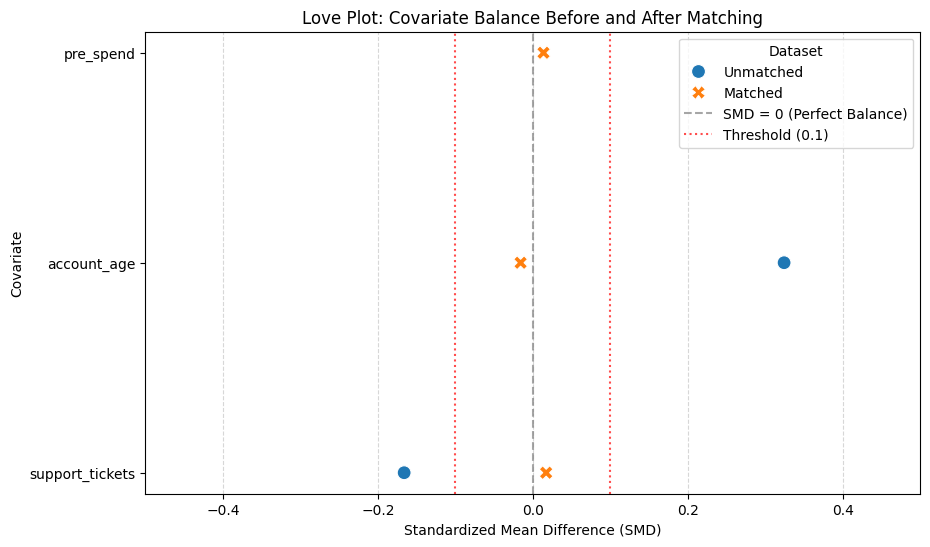

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
smd_melted = smd_comparison.melt(id_vars='Covariate', var_name='Group', value_name='SMD')

# Create the Love Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smd_melted, x='SMD', y='Covariate', hue='Group', style='Group', s=100, zorder=2)
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.7, label='SMD = 0 (Perfect Balance)')
plt.axvline(x=0.1, color='red', linestyle=':', alpha=0.7, label='Threshold (0.1)')
plt.axvline(x=-0.1, color='red', linestyle=':', alpha=0.7)
plt.title('Love Plot: Covariate Balance Before and After Matching')
plt.xlabel('Standardized Mean Difference (SMD)')
plt.ylabel('Covariate')
plt.legend(title='Dataset')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(-0.5, 0.5) # Adjust x-axis limits for better visualization
plt.show()


### Theoretical Visual Evidence for Successfully Mitigated Selection Bias (Love Plot Interpretation)

The 'Love Plot' visually assesses the balance of covariates between treatment and control groups before and after Propensity Score Matching. To conclusively prove that selection bias was successfully mitigated, you should observe the following:

1.  **Reduction in SMDs for Matched Data**: The primary evidence is a substantial reduction in the Standardized Mean Differences (SMDs) for the 'Matched' group compared to the 'Unmatched' group. This means the points representing the 'Matched' data should be significantly closer to zero on the x-axis for all covariates.

2.  **SMDs Closer to Zero**: Ideally, after matching, all covariate SMDs should be close to zero. A commonly accepted rule of thumb is that an absolute SMD value less than 0.1 (or sometimes 0.05) indicates adequate balance. In the plot, this means all 'Matched' points should fall within the red dashed lines (representing the +/- 0.1 threshold).

3.  **Consistency Across Covariates**: The improvement in balance should be observed across all relevant covariates used in the matching process. If some covariates remain imbalanced after matching, it suggests that the matching was not fully effective, and residual bias may still exist.

4.  **No New Imbalances**: While reducing imbalance on the matching covariates, ensure that matching does not inadvertently introduce new imbalances in other, unmeasured, but theoretically important covariates (though these would not appear on this specific plot). However, for the covariates explicitly plotted, the goal is consistent improvement.

In summary, the most compelling visual evidence is that all blue (unmatched) points are far from zero, while all orange (matched) points are clustered tightly around the central 'SMD = 0' line, ideally within the +/- 0.1 threshold for all covariates.